In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

1.0110997752220547
1.0110220440881763


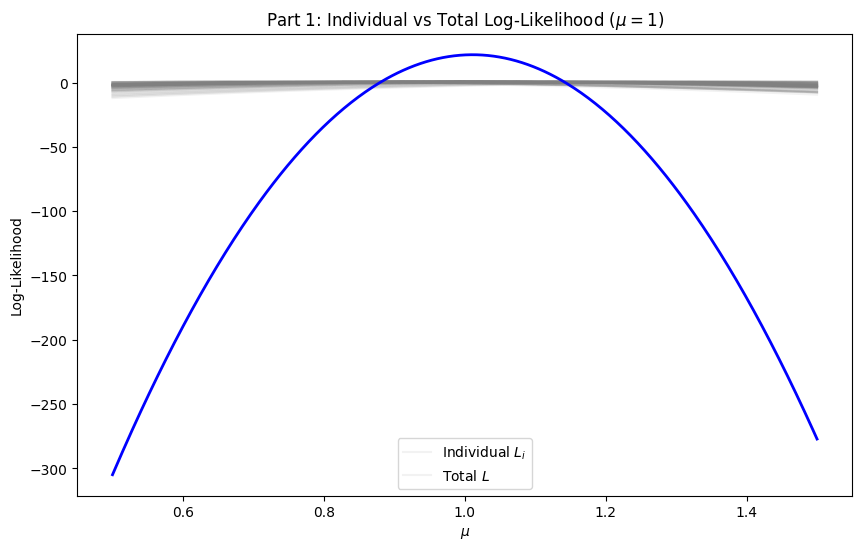

In [23]:
true_mean = 1
std = 0.2
N = 100
mean_vals = np.linspace(0.5, 1.5, 500)

xi = norm.rvs(true_mean, std, N)
indiv_log_likelihoods = norm.logpdf(xi[:, np.newaxis], loc=mean_vals, scale=std)
total_log_likelihood = indiv_log_likelihoods.sum(axis=0)

print(np.mean(xi))
print(mean_vals[np.argmax(total_log_likelihood)])

plt.figure(figsize=(10, 6))
plt.plot(mean_vals, indiv_log_likelihoods.T, color='gray', alpha=0.1) 
plt.plot(mean_vals, total_log_likelihood, color='blue', lw=2, label='Total Log-Likelihood')

plt.title("Part 1: Individual vs Total Log-Likelihood ($\mu=1$)")
plt.xlabel("$\mu$")
plt.ylabel("Log-Likelihood")
plt.legend(['Individual $L_i$', 'Total $L$'])
plt.show()

0.02
0.019999999999999685


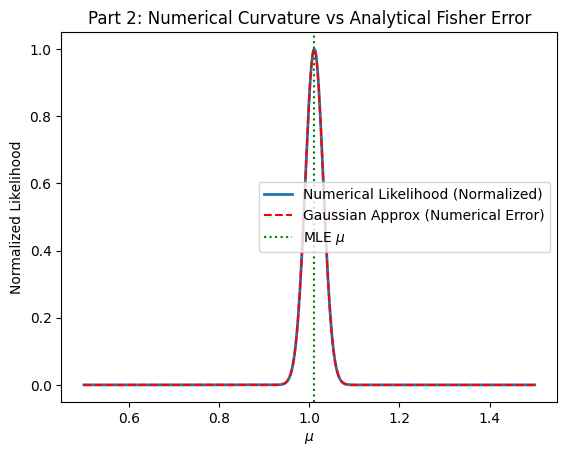

In [31]:
fisher_error = std/np.sqrt(N)
mean_mle = mean_vals[np.argmax(total_log_likelihood)]
dmu = mean_vals[1] - mean_vals[0]
d2_ll = np.diff(total_log_likelihood, n=2) / dmu**2
peak_curv = d2_ll[np.argmax(total_log_likelihood) - 1]
num_error = np.sqrt(-1 / peak_curv)
print(fisher_error)
print(num_error)

likelihood_norm = np.exp(total_log_likelihood - np.max(total_log_likelihood))
plt.plot(mean_vals, likelihood_norm, label='Numerical Likelihood (Normalized)', lw=2)

gaussian_approx = norm.pdf(mean_vals, loc=mean_mle, scale=num_error)
plt.plot(mean_vals, gaussian_approx / np.max(gaussian_approx), '--', 
         label='Gaussian Approx (Numerical Error)', color='red')

plt.axvline(mean_mle, color='green', linestyle=':', label=f'MLE $\mu$')
plt.title("Part 2: Numerical Curvature vs Analytical Fisher Error")
plt.xlabel(r"$\mu$")
plt.ylabel("Normalized Likelihood")
plt.legend()
plt.show()

1.0206899024956158
0.01744979040242859
1.0210420841683367


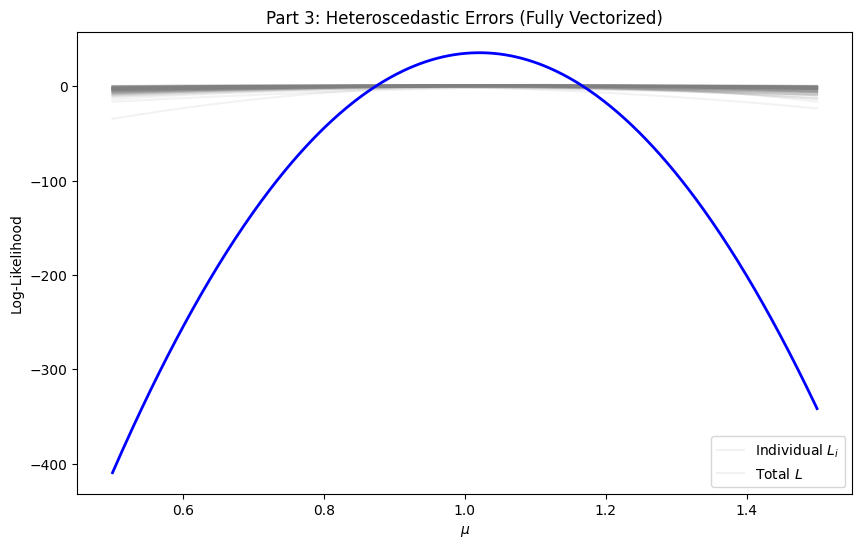

In [39]:
stds_het = norm.rvs(loc=0.2, scale=0.05, size=N, random_state=42)
# Generate data points using their specific sigmas
xi_het = norm.rvs(loc=true_mean, scale=stds_het)

log_probs = norm.logpdf(xi_het[:, np.newaxis], loc=mean_vals[np.newaxis, :], scale=stds_het[:, np.newaxis])
total_ll = log_probs.sum(axis=0)

weights = 1.0 / stds_het**2
mean_mle_het = np.sum(xi_het * weights) / np.sum(weights)
fisher_error_het = np.sqrt(1.0 / np.sum(weights))

print(mean_mle_het)
print(fisher_error_het)
print(mean_vals[np.argmax(total_ll)])

plt.figure(figsize=(10, 6))
plt.plot(mean_vals, log_probs.T, color='gray', alpha=0.1) # Individual curves
plt.plot(mean_vals, total_ll, color='blue', lw=2, label='Total Log-Likelihood')
plt.title("Part 3: Heteroscedastic Errors (Fully Vectorized)")
plt.xlabel(r"$\mu$")
plt.ylabel("Log-Likelihood")
plt.legend(['Individual $L_i$', 'Total $L$'])
plt.show()